# Week 2 — Data Integration & Foundational Analysis

## 1. Project Objective

Week 1 established the structure, keys, and data-quality profile of all 9 Olist tables (see
`notebooks/01_week1_data_audit.ipynb` and `docs/data_dictionary/`). Week 2 moves from *auditing*
the raw data to *integrating* it into a single, validated, order-level analytical extract.

**Goal:** build a cleaned, one-row-per-`order_id` extract by joining `orders`, `customers`,
`payments`, and `order_items`, while explicitly preventing the row multiplication that a naive
join would cause (`order_items` and `payments` are both one-to-many relative to `orders`).

This notebook:

- Loads only the source tables required for this scope (`orders`, `customers`, `payments`,
  `order_items`). The raw source-table DataFrames are kept unmodified and are never overwritten;
  all transformations happen on separate, explicitly named copies.
- Documents the **grain** of each source table using actual uniqueness checks, not assumptions.
- Runs **reusable join-key validation logic** on every relationship used in the join flow, with
  PASS / WARNING / FAIL results driven entirely by the real data.
- **Aggregates `order_items` and `payments` to one row per `order_id` before joining them** to
  `orders`, so the final extract cannot be multiplied by the one-to-many relationship on either
  side.
- Validates the resulting extract (uniqueness, row counts, reconciliation of source totals) and
  reports — rather than silently drops — any unmatched or missing records.
- Produces five foundational charts on order volume and payment behavior.
- Exports the cleaned order-level extract to `data/processed/olist_order_level_cleaned.csv`.

**Explicitly out of scope for Week 2** (per the faculty brief): RFM, CLV, customer segmentation,
the final Tableau dashboard, and machine learning. `customer_unique_id` is carried into the
extract as a column (per the Week 1 finding that it is the real customer identity), but no
customer-level aggregation or deduplication is performed here — the extract stays at the
`order_id` grain throughout.


## 2. Load Source Tables

Only the tables required for the Week 2 join flow are loaded: `orders`, `customers`, `payments`,
and `order_items`. `products`, `sellers`, `reviews`, `geolocation`, and `category_translation`
are **not** loaded — none of the required aggregates (Section 7's `distinct_products` /
`distinct_sellers` can be computed directly from the `product_id` / `seller_id` columns already
present in `order_items`) or the five foundational charts need them, and loading them would
expand the core extract beyond what this week's scope calls for (Rule 7: do not blindly join all
source tables together).

Each table is loaded directly from `data/raw/` into its own separate, explicitly named DataFrame.
These raw DataFrames are treated as read-only for the rest of the notebook — every transformation
below (enrichment, aggregation, joining) is performed on new variables, never by mutating these.


In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown

print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("Environment setup successful!")

Python: 3.12.14 (main, Aug 12 2026, 13:57:54) [Clang 21.0.0 (clang-2100.1.1.101)]
Pandas: 3.0.5
Environment setup successful!


In [2]:
RAW_DATA_DIR = Path("../data/raw")
PROCESSED_DATA_DIR = Path("../data/processed")

file_map = {
    "orders": "olist_orders_dataset.csv",
    "customers": "olist_customers_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
}

dfs = {}
for name, filename in file_map.items():
    filepath = RAW_DATA_DIR / filename
    dfs[name] = pd.read_csv(filepath)
    print(f"Loaded '{name}': {dfs[name].shape[0]:>7,} rows x {dfs[name].shape[1]:>2} columns  <- {filename}")

assert len(dfs) == 4, f"Expected 4 source tables, loaded {len(dfs)}"
print(f"\nAll {len(dfs)} required source tables loaded successfully into `dfs` (raw, unmodified).")

# Keep the four source-table DataFrames as separate, explicitly named references.
# These are never mutated in place -- all work below happens on new variables.
orders_raw = dfs["orders"]
customers_raw = dfs["customers"]
payments_raw = dfs["payments"]
order_items_raw = dfs["order_items"]

Loaded 'orders':  99,441 rows x  8 columns  <- olist_orders_dataset.csv
Loaded 'customers':  99,441 rows x  5 columns  <- olist_customers_dataset.csv
Loaded 'payments': 103,886 rows x  5 columns  <- olist_order_payments_dataset.csv


Loaded 'order_items': 112,650 rows x  7 columns  <- olist_order_items_dataset.csv

All 4 required source tables loaded successfully into `dfs` (raw, unmodified).


## 3. Source Table Grain

Before joining anything, we document the actual grain of each source table using real
uniqueness checks — no relationship is assumed to be one-to-one unless the data proves it.

Expected grain:

- **`orders`** → one row per order (`order_id` expected unique)
- **`customers`** → one row per order-scoped customer record (`customer_id` expected unique;
  `customer_unique_id` is **not** expected to be unique — see Week 1 findings)
- **`order_items`** → one row per item within an order (`order_id` **not** expected to be unique;
  the real per-row key is the composite `(order_id, order_item_id)`)
- **`payments`** → one row per payment record (`order_id` **not** expected to be unique; the real
  per-row key is the composite `(order_id, payment_sequential)`)


In [3]:
grain_checks = pd.DataFrame([
    {
        "table": "orders",
        "expected_grain": "one row per order",
        "grain_key": "order_id",
        "total_rows": len(orders_raw),
        "unique_key_values": int(orders_raw["order_id"].nunique()),
        "key_is_unique": bool(orders_raw["order_id"].is_unique),
    },
    {
        "table": "customers",
        "expected_grain": "one row per order-scoped customer record",
        "grain_key": "customer_id",
        "total_rows": len(customers_raw),
        "unique_key_values": int(customers_raw["customer_id"].nunique()),
        "key_is_unique": bool(customers_raw["customer_id"].is_unique),
    },
    {
        "table": "order_items",
        "expected_grain": "one row per item within an order (order_id is one-to-many)",
        "grain_key": "order_id",
        "total_rows": len(order_items_raw),
        "unique_key_values": int(order_items_raw["order_id"].nunique()),
        "key_is_unique": bool(order_items_raw["order_id"].is_unique),
    },
    {
        "table": "payments",
        "expected_grain": "one row per payment record (order_id is one-to-many)",
        "grain_key": "order_id",
        "total_rows": len(payments_raw),
        "unique_key_values": int(payments_raw["order_id"].nunique()),
        "key_is_unique": bool(payments_raw["order_id"].is_unique),
    },
])
display(grain_checks)

,table,expected_grain,grain_key,total_rows,unique_key_values,key_is_unique
0,orders,one row per order,order_id,99441,99441,True
1,customers,one row per order-scoped customer record,customer_id,99441,99441,True
2,order_items,one row per item within an order (order_id is ...,order_id,112650,98666,False
3,payments,one row per payment record (order_id is one-to...,order_id,103886,99440,False


In [4]:
# order_items and payments are not expected to be unique on order_id alone -- confirm their
# true per-row grain is the documented composite key instead.
order_items_composite_unique = bool(~order_items_raw.duplicated(subset=["order_id", "order_item_id"]).any())
payments_composite_unique = bool(~payments_raw.duplicated(subset=["order_id", "payment_sequential"]).any())

avg_items_per_order = order_items_raw.groupby("order_id").size().mean()
max_items_per_order = order_items_raw.groupby("order_id").size().max()
avg_payments_per_order = payments_raw.groupby("order_id").size().mean()
max_payments_per_order = payments_raw.groupby("order_id").size().max()

print(f"order_items: (order_id, order_item_id) composite key unique -> {order_items_composite_unique}")
print(f"  average items per order_id: {avg_items_per_order:.3f} | max items for a single order_id: {int(max_items_per_order)}")
print()
print(f"payments: (order_id, payment_sequential) composite key unique -> {payments_composite_unique}")
print(f"  average payment rows per order_id: {avg_payments_per_order:.3f} | max payment rows for a single order_id: {int(max_payments_per_order)}")

order_items: (order_id, order_item_id) composite key unique -> True
  average items per order_id: 1.142 | max items for a single order_id: 21

payments: (order_id, payment_sequential) composite key unique -> True
  average payment rows per order_id: 1.045 | max payment rows for a single order_id: 29


**Grain conclusion (from the checks above):** `orders.order_id` and `customers.customer_id`
are both verified unique -- one row per order and one row per order-scoped customer record,
respectively. `order_items.order_id` and `payments.order_id` are both verified **not** unique --
confirming they are one-to-many relative to `orders` at the raw grain, with their true per-row
uniqueness instead coming from the composite keys `(order_id, order_item_id)` and
`(order_id, payment_sequential)`. This is exactly why `order_items` and `payments` must be
aggregated to one row per `order_id` (Sections 6-7) before being joined into an order-level
extract -- joining either of them directly to `orders` would multiply order rows.


## 4. Join-Key Validation

Reusable validation logic (`validate_join`) checks each relationship actually used in the Week 2
join flow, purely from the loaded data:

- **A.** `orders.customer_id` → `customers.customer_id`
- **B.** `order_items.order_id` → `orders.order_id`
- **C.** `payments.order_id` → `orders.order_id`

For each relationship, the function reports the parent/child table and key, the number of child
rows and unique child keys, unmatched child rows and their percentage, the inferred cardinality,
and a PASS / WARNING / FAIL status (PASS = 0% unmatched, WARNING = >0% and ≤1% unmatched,
FAIL = >1% unmatched). Nothing here is hard-coded — every value is computed from the actual
DataFrames.


In [5]:
def validate_join(parent_df, parent_key, parent_name, child_df, child_key, child_name):
    """Validate a child -> parent join key relationship directly from the data:
    reports match/unmatch counts and infers cardinality, without assuming 1:1."""
    parent_series = parent_df[parent_key]
    child_series = child_df[child_key]

    parent_values = set(parent_series.dropna())
    child_rows = len(child_df)
    unique_child_keys = int(child_series.nunique())

    unmatched_mask = child_series.notna() & ~child_series.isin(parent_values)
    unmatched_child_rows = int(unmatched_mask.sum())
    unmatched_percentage = round(unmatched_child_rows / child_rows * 100, 4) if child_rows else 0.0

    parent_key_unique = bool(parent_series.dropna().is_unique)
    child_key_has_duplicates = bool(child_series.dropna().duplicated().any())
    if parent_key_unique and not child_key_has_duplicates:
        cardinality = "1:1"
    elif parent_key_unique and child_key_has_duplicates:
        cardinality = "1:many"
    elif (not parent_key_unique) and child_key_has_duplicates:
        cardinality = "many:many"
    else:
        cardinality = "many:1"

    if unmatched_child_rows == 0:
        status = "PASS"
    elif unmatched_percentage <= 1:
        status = "WARNING"
    else:
        status = "FAIL"

    return {
        "relationship": f"{child_name}.{child_key} -> {parent_name}.{parent_key}",
        "parent_table": parent_name,
        "parent_key": parent_key,
        "child_table": child_name,
        "child_key": child_key,
        "child_rows": child_rows,
        "unique_child_keys": unique_child_keys,
        "unmatched_child_rows": unmatched_child_rows,
        "unmatched_percentage": unmatched_percentage,
        "cardinality": cardinality,
        "status": status,
    }


join_key_checks = [
    validate_join(customers_raw, "customer_id", "customers", orders_raw, "customer_id", "orders"),
    validate_join(orders_raw, "order_id", "orders", order_items_raw, "order_id", "order_items"),
    validate_join(orders_raw, "order_id", "orders", payments_raw, "order_id", "payments"),
]

join_key_validation = pd.DataFrame(join_key_checks)
display(join_key_validation)

,relationship,parent_table,parent_key,child_table,child_key,child_rows,unique_child_keys,unmatched_child_rows,unmatched_percentage,cardinality,status
0,orders.customer_id -> customers.customer_id,customers,customer_id,orders,customer_id,99441,99441,0,0.0,1:1,PASS
1,order_items.order_id -> orders.order_id,orders,order_id,order_items,order_id,112650,98666,0,0.0,1:many,PASS
2,payments.order_id -> orders.order_id,orders,order_id,payments,order_id,103886,99440,0,0.0,1:many,PASS


In [6]:
worst_status = "PASS"
if (join_key_validation["status"] == "FAIL").any():
    worst_status = "FAIL"
elif (join_key_validation["status"] == "WARNING").any():
    worst_status = "WARNING"

n_checks = len(join_key_validation)
n_pass = int((join_key_validation["status"] == "PASS").sum())
total_unmatched = int(join_key_validation["unmatched_child_rows"].sum())

summary_lines = "\n".join(
    f"- **{row.relationship}** — cardinality **{row.cardinality}**, "
    f"{row.unmatched_child_rows:,} / {row.child_rows:,} unmatched ({row.unmatched_percentage}%) -> **{row.status}**"
    for row in join_key_validation.itertuples()
)

display(Markdown(
    f"### Join-Key Validation Results\n\n"
    f"{n_pass} of {n_checks} checked relationships PASS with 0% unmatched rows; overall worst status "
    f"across all checks is **{worst_status}** ({total_unmatched:,} total unmatched child rows across all checks).\n\n"
    f"{summary_lines}\n\n"
    f"**Cardinality implication for the join flow:** relationship A (`orders -> customers`) is 1:1, so joining "
    f"customer attributes onto `orders` cannot multiply order rows. Relationships B and C "
    f"(`order_items -> orders`, `payments -> orders`) are 1:many -- joining either of these directly onto "
    f"`orders` **would** multiply order rows, which is exactly why Sections 6-7 aggregate both to one row "
    f"per `order_id` before they are joined in Section 8."
))

### Join-Key Validation Results

3 of 3 checked relationships PASS with 0% unmatched rows; overall worst status across all checks is **PASS** (0 total unmatched child rows across all checks).

- **orders.customer_id -> customers.customer_id** — cardinality **1:1**, 0 / 99,441 unmatched (0.0%) -> **PASS**
- **order_items.order_id -> orders.order_id** — cardinality **1:many**, 0 / 112,650 unmatched (0.0%) -> **PASS**
- **payments.order_id -> orders.order_id** — cardinality **1:many**, 0 / 103,886 unmatched (0.0%) -> **PASS**

**Cardinality implication for the join flow:** relationship A (`orders -> customers`) is 1:1, so joining customer attributes onto `orders` cannot multiply order rows. Relationships B and C (`order_items -> orders`, `payments -> orders`) are 1:many -- joining either of these directly onto `orders` **would** multiply order rows, which is exactly why Sections 6-7 aggregate both to one row per `order_id` before they are joined in Section 8.

## 5. Customer Enrichment

A customer lookup is built from `customers` with just the columns needed for enrichment:
`customer_id`, `customer_unique_id`, `customer_zip_code_prefix`, `customer_city`, and
`customer_state`. Since Section 4 confirmed `orders.customer_id -> customers.customer_id` is a
clean 1:1 relationship (0% unmatched), this can be safely left-joined onto `orders` without
multiplying rows or losing orders.

`customer_unique_id` is **not** deduplicated at this stage — `orders` must stay at the
`order_id` grain, and a real customer with multiple orders should keep appearing once per order,
each row carrying that customer's shared `customer_unique_id`.


In [7]:
customer_lookup = customers_raw[
    ["customer_id", "customer_unique_id", "customer_zip_code_prefix", "customer_city", "customer_state"]
].copy()

print(f"customer_lookup: {len(customer_lookup):,} rows | customer_id unique: {bool(customer_lookup['customer_id'].is_unique)}")

rows_before_enrichment = len(orders_raw)

orders_customers = orders_raw.merge(customer_lookup, on="customer_id", how="left")

rows_after_enrichment = len(orders_customers)
order_id_unique_after_enrichment = bool(orders_customers["order_id"].is_unique)
unmatched_orders_after_enrichment = int(orders_customers["customer_unique_id"].isna().sum())

print(f"orders rows before enrichment: {rows_before_enrichment:,}")
print(f"orders rows after enrichment:  {rows_after_enrichment:,}")
print(f"row count unchanged (no multiplication): {rows_before_enrichment == rows_after_enrichment}")
print(f"order_id still unique after enrichment: {order_id_unique_after_enrichment}")
print(f"orders with no matching customer record (unmatched): {unmatched_orders_after_enrichment:,}")

assert rows_before_enrichment == rows_after_enrichment, "Customer enrichment changed the row count -- unexpected row multiplication!"
assert order_id_unique_after_enrichment, "order_id is no longer unique after customer enrichment!"

display(orders_customers.head(3))

customer_lookup: 99,441 rows | customer_id unique: True
orders rows before enrichment: 99,441
orders rows after enrichment:  99,441
row count unchanged (no multiplication): True
order_id still unique after enrichment: True
orders with no matching customer record (unmatched): 0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


## 6. Payment Aggregation

`payments` is one-to-many relative to `orders` (Sections 3-4). It is **never joined directly**
to `orders` in raw form — it is first aggregated to exactly one row per `order_id`.

Aggregates computed:

- `total_payment_value` — sum of `payment_value` across all payment rows for the order
- `payment_count` — number of payment rows for the order
- `payment_type_count` — number of distinct `payment_type` values used for the order
- `total_installments` — sum of `payment_installments` across all payment rows for the order

**Representative payment type for multi-payment orders:** an order can be paid with more than one
payment row (e.g. a credit card plus a voucher). Rather than arbitrarily keeping the first or last
row, `primary_payment_type` is defined as **the payment type with the highest total
`payment_value` for that order** (ties broken by whichever type is encountered first in the
source data). This directly reflects which payment method actually carried most of the order's
value, and is documented here explicitly so any chart or downstream use of it is interpreted
correctly.


In [8]:
payment_agg = (
    payments_raw.groupby("order_id")
    .agg(
        total_payment_value=("payment_value", "sum"),
        payment_count=("payment_value", "size"),
        payment_type_count=("payment_type", "nunique"),
        total_installments=("payment_installments", "sum"),
    )
    .reset_index()
)

# Representative ("primary") payment type per order: the type with the highest total payment_value
# for that order. Computed from payments_raw directly, not arbitrarily from row order.
payment_type_value = (
    payments_raw.groupby(["order_id", "payment_type"])["payment_value"].sum().reset_index()
)
primary_idx = payment_type_value.groupby("order_id")["payment_value"].idxmax()
primary_payment_type = (
    payment_type_value.loc[primary_idx, ["order_id", "payment_type"]]
    .rename(columns={"payment_type": "primary_payment_type"})
    .reset_index(drop=True)
)

payment_agg = payment_agg.merge(primary_payment_type, on="order_id", how="left")

print(f"payment_agg: {len(payment_agg):,} rows (one row per order_id with at least one payment record)")
display(payment_agg.head(3))

payment_agg: 99,440 rows (one row per order_id with at least one payment record)


,order_id,total_payment_value,payment_count,payment_type_count,total_installments,primary_payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1,1,2,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,1,1,3,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,1,1,5,credit_card


In [9]:
# Validation: aggregation produced one row per order_id, matching the distinct order_id
# population in the raw payments table (no orders gained or lost by aggregating).
payment_agg_order_id_unique = bool(payment_agg["order_id"].is_unique)
n_distinct_orders_in_payments_raw = int(payments_raw["order_id"].nunique())
n_orders_in_payment_agg = len(payment_agg)

print(f"payment_agg order_id is unique: {payment_agg_order_id_unique}")
print(f"distinct order_id values in raw payments: {n_distinct_orders_in_payments_raw:,}")
print(f"rows in payment_agg: {n_orders_in_payment_agg:,}")
print(f"aggregation preserved the distinct-order population: {n_distinct_orders_in_payments_raw == n_orders_in_payment_agg}")

assert payment_agg_order_id_unique, "payment_agg is not unique on order_id!"
assert n_distinct_orders_in_payments_raw == n_orders_in_payment_agg, "Payment aggregation changed the number of distinct orders!"

# Reconciliation: aggregated total_payment_value must sum back to the raw payments total.
raw_payment_value_total = payments_raw["payment_value"].sum()
agg_payment_value_total = payment_agg["total_payment_value"].sum()
payment_value_reconciles = bool(np.isclose(raw_payment_value_total, agg_payment_value_total, atol=0.01))

raw_payment_count_total = len(payments_raw)
agg_payment_count_total = int(payment_agg["payment_count"].sum())
payment_count_reconciles = raw_payment_count_total == agg_payment_count_total

print()
print(f"raw payments total payment_value:      {raw_payment_value_total:,.2f}")
print(f"payment_agg sum of total_payment_value: {agg_payment_value_total:,.2f}")
print(f"payment value reconciles: {payment_value_reconciles}")
print()
print(f"raw payments row count:          {raw_payment_count_total:,}")
print(f"payment_agg sum of payment_count: {agg_payment_count_total:,}")
print(f"payment row count reconciles: {payment_count_reconciles}")

assert payment_value_reconciles, "total_payment_value does not reconcile to the raw payments table!"
assert payment_count_reconciles, "payment_count does not reconcile to the raw payments row count!"


payment_agg order_id is unique: True
distinct order_id values in raw payments: 99,440
rows in payment_agg: 99,440
aggregation preserved the distinct-order population: True

raw payments total payment_value:      16,008,872.12
payment_agg sum of total_payment_value: 16,008,872.12
payment value reconciles: True

raw payments row count:          103,886
payment_agg sum of payment_count: 103,886
payment row count reconciles: True


## 7. Order Item Aggregation

`order_items` is one-to-many relative to `orders` (Sections 3-4). Like `payments`, it is **never
joined directly** to `orders` — it is first aggregated to exactly one row per `order_id`.

Aggregates computed:

- `total_order_items` — number of item rows (line items) for the order
- `distinct_products` — number of distinct `product_id` values in the order
- `distinct_sellers` — number of distinct `seller_id` values in the order
- `total_product_value` — sum of `price` across all items in the order
- `total_freight_value` — sum of `freight_value` across all items in the order


In [10]:
order_item_agg = (
    order_items_raw.groupby("order_id")
    .agg(
        total_order_items=("order_item_id", "count"),
        distinct_products=("product_id", "nunique"),
        distinct_sellers=("seller_id", "nunique"),
        total_product_value=("price", "sum"),
        total_freight_value=("freight_value", "sum"),
    )
    .reset_index()
)

print(f"order_item_agg: {len(order_item_agg):,} rows (one row per order_id with at least one item)")
display(order_item_agg.head(3))

order_item_agg: 98,666 rows (one row per order_id with at least one item)


,order_id,total_order_items,distinct_products,distinct_sellers,total_product_value,total_freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,1,1,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,1,1,199.0,17.87


In [11]:
# Validation: aggregated order_id is unique, and reconciles to the distinct-order population
# in raw order_items.
order_item_agg_order_id_unique = bool(order_item_agg["order_id"].is_unique)
n_distinct_orders_in_items_raw = int(order_items_raw["order_id"].nunique())
n_orders_in_item_agg = len(order_item_agg)

print(f"order_item_agg order_id is unique: {order_item_agg_order_id_unique}")
print(f"distinct order_id values in raw order_items: {n_distinct_orders_in_items_raw:,}")
print(f"rows in order_item_agg: {n_orders_in_item_agg:,}")
print(f"aggregation preserved the distinct-order population: {n_distinct_orders_in_items_raw == n_orders_in_item_agg}")

assert order_item_agg_order_id_unique, "order_item_agg is not unique on order_id!"
assert n_distinct_orders_in_items_raw == n_orders_in_item_agg, "Order-item aggregation changed the number of distinct orders!"

# Reconciliation: aggregated sums must match the raw order_items totals exactly.
raw_product_value_total = order_items_raw["price"].sum()
agg_product_value_total = order_item_agg["total_product_value"].sum()
product_value_reconciles = bool(np.isclose(raw_product_value_total, agg_product_value_total, atol=0.01))

raw_freight_value_total = order_items_raw["freight_value"].sum()
agg_freight_value_total = order_item_agg["total_freight_value"].sum()
freight_value_reconciles = bool(np.isclose(raw_freight_value_total, agg_freight_value_total, atol=0.01))

raw_item_row_count = len(order_items_raw)
agg_item_row_count = int(order_item_agg["total_order_items"].sum())
item_row_count_reconciles = raw_item_row_count == agg_item_row_count

print()
print(f"raw order_items total price:            {raw_product_value_total:,.2f}")
print(f"order_item_agg sum of total_product_value: {agg_product_value_total:,.2f}")
print(f"product value reconciles: {product_value_reconciles}")
print()
print(f"raw order_items total freight_value:       {raw_freight_value_total:,.2f}")
print(f"order_item_agg sum of total_freight_value: {agg_freight_value_total:,.2f}")
print(f"freight value reconciles: {freight_value_reconciles}")
print()
print(f"raw order_items row count:              {raw_item_row_count:,}")
print(f"order_item_agg sum of total_order_items: {agg_item_row_count:,}")
print(f"item row count reconciles: {item_row_count_reconciles}")

assert product_value_reconciles, "total_product_value does not reconcile to raw order_items!"
assert freight_value_reconciles, "total_freight_value does not reconcile to raw order_items!"
assert item_row_count_reconciles, "total_order_items does not reconcile to the raw order_items row count!"


order_item_agg order_id is unique: True
distinct order_id values in raw order_items: 98,666
rows in order_item_agg: 98,666
aggregation preserved the distinct-order population: True

raw order_items total price:            13,591,643.70
order_item_agg sum of total_product_value: 13,591,643.70
product value reconciles: True

raw order_items total freight_value:       2,251,909.54
order_item_agg sum of total_freight_value: 2,251,909.54
freight value reconciles: True

raw order_items row count:              112,650
order_item_agg sum of total_order_items: 112,650
item row count reconciles: True


**Orders with no item or payment rows:** not every order necessarily has at least one
`order_items` row or one `payments` row (e.g. a cancelled order may never have been fulfilled or
paid). Rather than assuming this away, the actual unmatched counts are measured directly below,
and are carried forward — not silently dropped — into the final extract (Section 8).


In [12]:
order_ids_all = set(orders_raw["order_id"])
order_ids_with_items = set(order_items_raw["order_id"])
order_ids_with_payments = set(payments_raw["order_id"])

orders_without_items = order_ids_all - order_ids_with_items
orders_without_payments = order_ids_all - order_ids_with_payments

print(f"orders with NO order_items rows:  {len(orders_without_items):,} ({len(orders_without_items) / len(order_ids_all) * 100:.3f}%)")
print(f"orders with NO payments rows:     {len(orders_without_payments):,} ({len(orders_without_payments) / len(order_ids_all) * 100:.3f}%)")
print()
print("order_status breakdown for orders with no order_items rows:")
display(orders_raw[orders_raw["order_id"].isin(orders_without_items)]["order_status"].value_counts().rename("count").to_frame())
print()
print("order_status breakdown for orders with no payments rows:")
display(orders_raw[orders_raw["order_id"].isin(orders_without_payments)]["order_status"].value_counts().rename("count").to_frame())

orders with NO order_items rows:  775 (0.779%)
orders with NO payments rows:     1 (0.001%)

order_status breakdown for orders with no order_items rows:


,count
order_status,
unavailable,603
canceled,164
created,5
invoiced,2
shipped,1



order_status breakdown for orders with no payments rows:


,count
order_status,
delivered,1


## 8. Build the Cleaned Order-Level Extract

The order-level extract is assembled by taking the customer-enriched orders table
(`orders_customers`, Section 5, already one row per `order_id`) and **left-joining the two
pre-aggregated tables** onto it — `order_item_agg` and `payment_agg` — both of which are already
one row per `order_id` (Sections 6-7). Because every piece being joined is one row per
`order_id`, this cannot multiply order rows, unlike joining the raw `order_items` / `payments`
tables directly would.

A left join (not inner) is used for the item and payment aggregates so that orders with no
matching item or payment rows (Section 7) are **kept, not dropped** — for these orders, the
count/sum aggregate fields are the correct aggregate of an empty group (`0`), and
`primary_payment_type` is left missing (`NaN`) since no payment type exists to report. This is a
true, computed aggregate over zero rows, not an imputed guess, and the affected order counts are
reported explicitly below rather than hidden.


In [13]:
ORDER_LEVEL_GRAIN_KEY = "order_id"

order_level_extract = orders_customers.merge(order_item_agg, on="order_id", how="left")
order_level_extract = order_level_extract.merge(payment_agg, on="order_id", how="left")

print(f"orders_customers rows:    {len(orders_customers):,}")
print(f"order_level_extract rows: {len(order_level_extract):,}")
print(f"row count preserved through both aggregate joins: {len(orders_customers) == len(order_level_extract)}")
assert len(orders_customers) == len(order_level_extract), "Joining the aggregates changed the row count -- unexpected multiplication!"

# Count-type aggregate fields are 0 (a true aggregate of an empty group), not missing, for orders
# with no matching item/payment rows. primary_payment_type stays NaN -- there is no payment type
# to report for an order with zero payment rows.
count_and_sum_cols = [
    "total_order_items", "distinct_products", "distinct_sellers", "total_product_value", "total_freight_value",
    "total_payment_value", "payment_count", "payment_type_count", "total_installments",
]
n_missing_items_before_fill = int(order_level_extract["total_order_items"].isna().sum())
n_missing_payments_before_fill = int(order_level_extract["payment_count"].isna().sum())

order_level_extract[count_and_sum_cols] = order_level_extract[count_and_sum_cols].fillna(0)
for col in ["total_order_items", "distinct_products", "distinct_sellers", "payment_count", "payment_type_count", "total_installments"]:
    order_level_extract[col] = order_level_extract[col].astype(int)

order_level_extract["has_order_items"] = ~order_level_extract["order_id"].isin(orders_without_items)
order_level_extract["has_payment_records"] = ~order_level_extract["order_id"].isin(orders_without_payments)

print(f"orders with no item rows (total_order_items set to 0): {n_missing_items_before_fill:,}")
print(f"orders with no payment rows (payment_count set to 0):  {n_missing_payments_before_fill:,}")

orders_customers rows:    99,441
order_level_extract rows: 99,441
row count preserved through both aggregate joins: True
orders with no item rows (total_order_items set to 0): 775
orders with no payment rows (payment_count set to 0):  1


In [14]:
order_fields = [
    "order_id", "customer_id", "order_status", "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date",
]
customer_fields = ["customer_unique_id", "customer_zip_code_prefix", "customer_city", "customer_state"]
item_agg_fields = ["total_order_items", "distinct_products", "distinct_sellers", "total_product_value", "total_freight_value"]
payment_agg_fields = ["total_payment_value", "payment_count", "payment_type_count", "total_installments", "primary_payment_type"]
flag_fields = ["has_order_items", "has_payment_records"]

final_columns = order_fields + customer_fields + item_agg_fields + payment_agg_fields + flag_fields
order_level_extract = order_level_extract[final_columns]

print(f"order_level_extract: {len(order_level_extract):,} rows x {order_level_extract.shape[1]} columns")
display(order_level_extract.head(5))

order_level_extract: 99,441 rows x 24 columns


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,distinct_sellers,total_product_value,total_freight_value,total_payment_value,payment_count,payment_type_count,total_installments,primary_payment_type,has_order_items,has_payment_records
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1,29.99,8.72,38.71,3,2,3,voucher,True,True
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,1,118.70,22.76,141.46,1,1,1,boleto,True,True
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1,159.90,19.22,179.12,1,1,3,credit_card,True,True
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,1,45.00,27.20,72.20,1,1,1,credit_card,True,True
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,1,19.90,8.72,28.62,1,1,1,credit_card,True,True


## 9. Extract Validation

A dedicated validation pass confirms the extract is correct before it is used for any charting
or export: uniqueness, row-count integrity through every join step, and reconciliation of
aggregated totals back to the original source tables. Any discrepancy would be investigated and
documented here, not hidden.


In [15]:
validation_rows = []

# 1. order_id is unique in the final extract.
order_id_unique_final = bool(order_level_extract["order_id"].is_unique)
validation_rows.append({
    "check": "order_id is unique in final extract",
    "expected": "True",
    "actual": str(order_id_unique_final),
    "status": "PASS" if order_id_unique_final else "FAIL",
})

# 2. Final row count matches the order-level population being used (orders_raw).
expected_row_count = len(orders_raw)
actual_row_count = len(order_level_extract)
validation_rows.append({
    "check": "final row count matches orders population",
    "expected": f"{expected_row_count:,} (len(orders_raw))",
    "actual": f"{actual_row_count:,}",
    "status": "PASS" if expected_row_count == actual_row_count else "FAIL",
})

# 3. No unexpected duplicate order_ids.
n_duplicate_order_ids = int(order_level_extract["order_id"].duplicated().sum())
validation_rows.append({
    "check": "no duplicate order_ids",
    "expected": "0",
    "actual": f"{n_duplicate_order_ids:,}",
    "status": "PASS" if n_duplicate_order_ids == 0 else "FAIL",
})

# 4. Customer enrichment did not multiply rows (measured back in Section 5).
validation_rows.append({
    "check": "customer enrichment preserved row count",
    "expected": f"{rows_before_enrichment:,}",
    "actual": f"{rows_after_enrichment:,}",
    "status": "PASS" if rows_before_enrichment == rows_after_enrichment else "FAIL",
})

# 5. Payment aggregation did not multiply orders.
validation_rows.append({
    "check": "payment aggregation preserved distinct-order count",
    "expected": f"{n_distinct_orders_in_payments_raw:,} distinct order_id in raw payments",
    "actual": f"{n_orders_in_payment_agg:,} rows in payment_agg",
    "status": "PASS" if n_distinct_orders_in_payments_raw == n_orders_in_payment_agg else "FAIL",
})

# 6. Order-item aggregation did not multiply orders.
validation_rows.append({
    "check": "order-item aggregation preserved distinct-order count",
    "expected": f"{n_distinct_orders_in_items_raw:,} distinct order_id in raw order_items",
    "actual": f"{n_orders_in_item_agg:,} rows in order_item_agg",
    "status": "PASS" if n_distinct_orders_in_items_raw == n_orders_in_item_agg else "FAIL",
})

# 7. Source totals reconcile with aggregated totals (payments + order_items).
extract_total_payment_value = order_level_extract["total_payment_value"].sum()
validation_rows.append({
    "check": "total_payment_value reconciles to raw payments",
    "expected": f"{raw_payment_value_total:,.2f}",
    "actual": f"{extract_total_payment_value:,.2f}",
    "status": "PASS" if np.isclose(raw_payment_value_total, extract_total_payment_value, atol=0.01) else "FAIL",
})

extract_total_product_value = order_level_extract["total_product_value"].sum()
validation_rows.append({
    "check": "total_product_value reconciles to raw order_items.price",
    "expected": f"{raw_product_value_total:,.2f}",
    "actual": f"{extract_total_product_value:,.2f}",
    "status": "PASS" if np.isclose(raw_product_value_total, extract_total_product_value, atol=0.01) else "FAIL",
})

extract_total_freight_value = order_level_extract["total_freight_value"].sum()
validation_rows.append({
    "check": "total_freight_value reconciles to raw order_items.freight_value",
    "expected": f"{raw_freight_value_total:,.2f}",
    "actual": f"{extract_total_freight_value:,.2f}",
    "status": "PASS" if np.isclose(raw_freight_value_total, extract_total_freight_value, atol=0.01) else "FAIL",
})

# Unmatched-record transparency (Rule 13: do not silently drop unmatched records).
validation_rows.append({
    "check": "orders with no matching customer record (reported, not dropped)",
    "expected": "measured from data",
    "actual": f"{unmatched_orders_after_enrichment:,}",
    "status": "PASS" if unmatched_orders_after_enrichment == 0 else "WARNING",
})
validation_rows.append({
    "check": "orders with no order_items rows (reported, not dropped)",
    "expected": "measured from data",
    "actual": f"{len(orders_without_items):,}",
    "status": "PASS" if len(orders_without_items) == 0 else "WARNING",
})
validation_rows.append({
    "check": "orders with no payments rows (reported, not dropped)",
    "expected": "measured from data",
    "actual": f"{len(orders_without_payments):,}",
    "status": "PASS" if len(orders_without_payments) == 0 else "WARNING",
})

validation_summary = pd.DataFrame(validation_rows)[["check", "expected", "actual", "status"]]
display(validation_summary)

n_fail = int((validation_summary["status"] == "FAIL").sum())
n_warning = int((validation_summary["status"] == "WARNING").sum())
print(f"\n{n_fail} FAIL, {n_warning} WARNING out of {len(validation_summary)} checks.")
assert n_fail == 0, "One or more extract validation checks FAILED -- see validation_summary above."


,check,expected,actual,status
0,order_id is unique in final extract,True,True,PASS
1,final row count matches orders population,"99,441 (len(orders_raw))","99,441",PASS
2,no duplicate order_ids,0,0,PASS
3,customer enrichment preserved row count,"99,441","99,441",PASS
4,payment aggregation preserved distinct-order c...,"99,440 distinct order_id in raw payments","99,440 rows in payment_agg",PASS
5,order-item aggregation preserved distinct-orde...,"98,666 distinct order_id in raw order_items","98,666 rows in order_item_agg",PASS
6,total_payment_value reconciles to raw payments,"16,008,872.12","16,008,872.12",PASS
7,total_product_value reconciles to raw order_it...,"13,591,643.70","13,591,643.70",PASS
8,total_freight_value reconciles to raw order_it...,"2,251,909.54","2,251,909.54",PASS
9,orders with no matching customer record (repor...,measured from data,0,PASS



0 FAIL, 2 WARNING out of 12 checks.


**Reconciliation note:** the two `WARNING`-eligible checks above (`orders with no order_items
rows`, `orders with no payments rows`) are **not** treated as failures — they reflect a real,
measured fact about the source data (some orders were cancelled/unavailable before ever being
fulfilled or paid), and the extract retains every one of these orders with `0`-valued aggregates
and `has_order_items` / `has_payment_records` flags rather than dropping them or invalidating the
extract. All row-multiplication and total-value reconciliation checks are hard `PASS`/`FAIL`
gates and the notebook stops (via `assert`) if any of them fail.


## 10. Foundational Visualizations

Five foundational charts, built entirely from the validated extract (or, where explicitly noted,
from the raw source table to avoid double-counting). No values below are hard-coded — every
title, axis, and figure is generated from the actual computed data.


### Chart 1 — Order Volume Over Time

Orders are grouped by calendar month using `order_purchase_timestamp` and plotted as a line
chart.


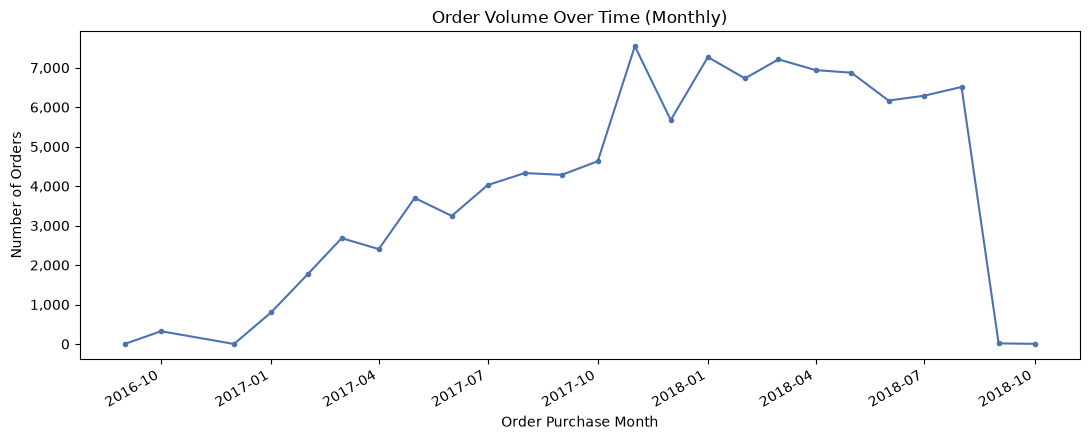

Months covered: 2016-09 to 2018-10
Peak month: 2017-11 with 7,544 orders


In [16]:
order_level_extract["order_purchase_timestamp"] = pd.to_datetime(order_level_extract["order_purchase_timestamp"])
monthly_order_volume = (
    order_level_extract
    .groupby(order_level_extract["order_purchase_timestamp"].dt.to_period("M"))
    .size()
    .rename("order_count")
)
monthly_order_volume.index = monthly_order_volume.index.to_timestamp()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(monthly_order_volume.index, monthly_order_volume.values, marker="o", markersize=3, color="#4C72B0", linewidth=1.5)
ax.set_title("Order Volume Over Time (Monthly)")
ax.set_xlabel("Order Purchase Month")
ax.set_ylabel("Number of Orders")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"Months covered: {monthly_order_volume.index.min().strftime('%Y-%m')} to {monthly_order_volume.index.max().strftime('%Y-%m')}")
print(f"Peak month: {monthly_order_volume.idxmax().strftime('%Y-%m')} with {int(monthly_order_volume.max()):,} orders")

### Chart 2 — Orders by Order Status

A bar chart of order counts for each `order_status` value.


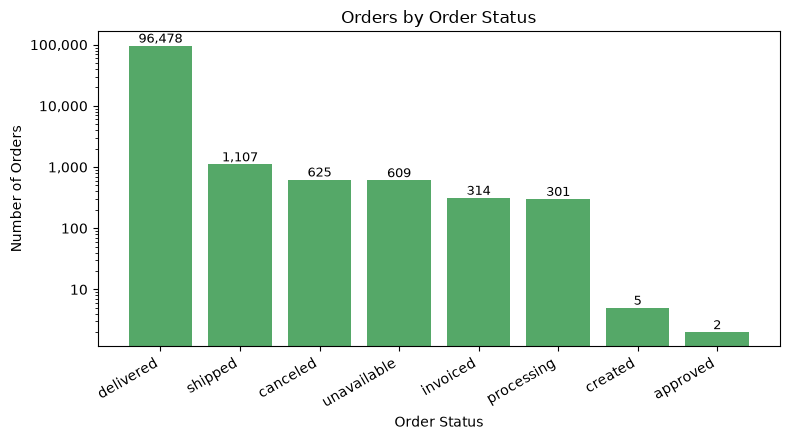

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [17]:
order_status_counts = order_level_extract["order_status"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(order_status_counts.index, order_status_counts.values, color="#55A868")
ax.set_title("Orders by Order Status")
ax.set_xlabel("Order Status")
ax.set_ylabel("Number of Orders")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, count in zip(bars, order_status_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{count:,}", ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

display(order_status_counts.rename("count").to_frame())

### Chart 3 — Payment Type Distribution

Uses the `primary_payment_type` documented and computed in Section 6 (the payment type carrying
the highest total `payment_value` for each order). Orders with no payment records at all
(`primary_payment_type` is `NaN` — see Section 7/9) are excluded from this order-count chart and
reported separately, rather than silently dropped.


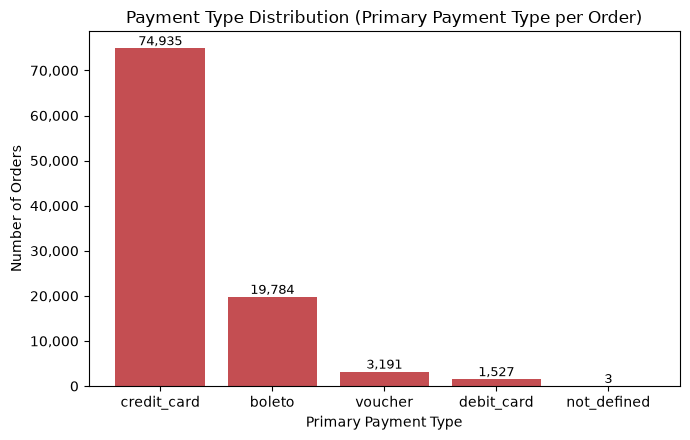

Orders with a determinable primary_payment_type: 99,440
Orders with no payment records (excluded from this chart, reported not dropped): 1
Orders paid with more than one distinct payment_type (primary_payment_type = the type with the highest payment_value for that order): 2,246


In [18]:
orders_with_primary_type = order_level_extract["primary_payment_type"].notna().sum()
orders_without_primary_type = order_level_extract["primary_payment_type"].isna().sum()

payment_type_dist = order_level_extract["primary_payment_type"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(payment_type_dist.index, payment_type_dist.values, color="#C44E52")
ax.set_title("Payment Type Distribution (Primary Payment Type per Order)")
ax.set_xlabel("Primary Payment Type")
ax.set_ylabel("Number of Orders")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, count in zip(bars, payment_type_dist.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{count:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Orders with a determinable primary_payment_type: {orders_with_primary_type:,}")
print(f"Orders with no payment records (excluded from this chart, reported not dropped): {orders_without_primary_type:,}")
n_multi_payment_type_orders = int((order_level_extract['payment_type_count'] > 1).sum())
print(f"Orders paid with more than one distinct payment_type (primary_payment_type = the type with the highest payment_value for that order): {n_multi_payment_type_orders:,}")

### Chart 4 — Payment Value by Payment Type

To avoid double counting, this chart is built directly from the **raw `payments` table**
(each payment row counted exactly once, grouped by its own `payment_type`) rather than from
`primary_payment_type`. Using the order-level primary type here would attribute an entire
multi-payment order's value to just one payment type; summing raw payment rows instead correctly
attributes each portion of value to the payment type that actually carried it.


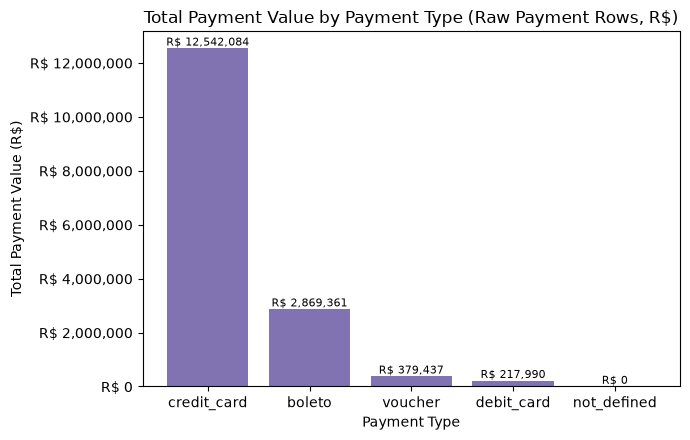

,total_payment_value
payment_type,
credit_card,12542084.19
boleto,2869361.27
voucher,379436.87
debit_card,217989.79
not_defined,0.00



Sum across payment types: R$ 16,008,872.12 | raw payments total: R$ 16,008,872.12 | matches: True


In [19]:
payment_value_by_type = payments_raw.groupby("payment_type")["payment_value"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(payment_value_by_type.index, payment_value_by_type.values, color="#8172B2")
ax.set_title("Total Payment Value by Payment Type (Raw Payment Rows, R$)")
ax.set_xlabel("Payment Type")
ax.set_ylabel("Total Payment Value (R$)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))
for bar, value in zip(bars, payment_value_by_type.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"R$ {value:,.0f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

display(payment_value_by_type.rename("total_payment_value").to_frame())
print(f"\nSum across payment types: R$ {payment_value_by_type.sum():,.2f} | raw payments total: R$ {raw_payment_value_total:,.2f} | matches: {np.isclose(payment_value_by_type.sum(), raw_payment_value_total, atol=0.01)}")

### Chart 5 — Order Value Distribution

A histogram of `total_product_value` from the extract, in Brazilian Reais (R$). Orders with no
recorded `order_items` (Section 7/9; `has_order_items == False`, `total_product_value == 0` by
construction) are excluded from this specific chart — a `0`-value order does not represent a real
order-value observation, and including it would distort the distribution. The excluded count is
reported explicitly, not hidden.


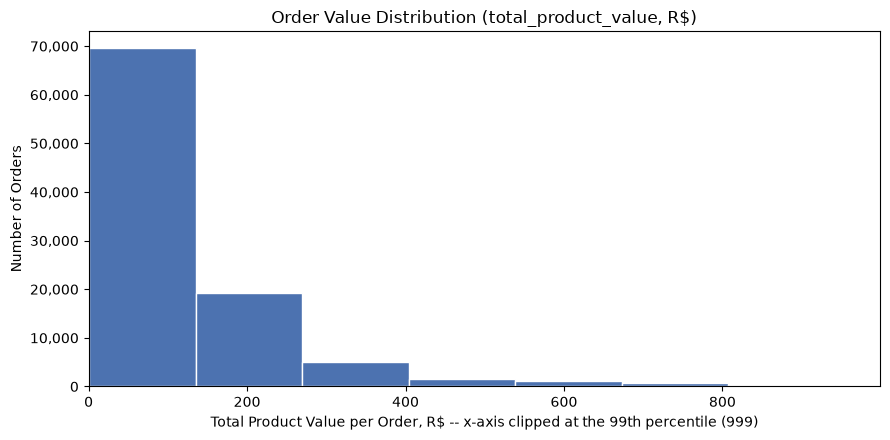

Orders included in this chart (has_order_items == True): 98,666
Orders excluded from the extract-level population (no order_items rows, total_product_value == 0 by construction): 775
Orders above the 99th-percentile x-axis view limit (still counted in the histogram bins, just off the visible range): 986



,total_product_value (R$)
count,98666.000000
mean,137.754076
std,210.645145
min,0.850000
25%,45.900000
50%,86.900000
75%,149.900000
max,13440.000000


In [20]:
orders_with_items_mask = order_level_extract["has_order_items"]
order_value_data = order_level_extract.loc[orders_with_items_mask, "total_product_value"]
n_excluded_from_chart5 = int((~orders_with_items_mask).sum())

# The distribution is heavily right-skewed (a small number of high-value orders). To keep the
# histogram readable, the x-axis view is clipped to the 99th percentile of the ACTUAL data (a
# data-driven cutoff, not a hard-coded value) -- every order is still counted in the underlying
# bins/statistics, only the visible axis range is limited for readability.
p99_cutoff = order_value_data.quantile(0.99)
n_beyond_p99 = int((order_value_data > p99_cutoff).sum())

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(order_value_data, bins=100, color="#4C72B0", edgecolor="white")
ax.set_xlim(0, p99_cutoff)
ax.set_title("Order Value Distribution (total_product_value, R$)")
ax.set_xlabel(f"Total Product Value per Order, R$ -- x-axis clipped at the 99th percentile ({p99_cutoff:,.0f})")
ax.set_ylabel("Number of Orders")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

print(f"Orders included in this chart (has_order_items == True): {len(order_value_data):,}")
print(f"Orders excluded from the extract-level population (no order_items rows, total_product_value == 0 by construction): {n_excluded_from_chart5:,}")
print(f"Orders above the 99th-percentile x-axis view limit (still counted in the histogram bins, just off the visible range): {n_beyond_p99:,}")
print()
display(order_value_data.describe().rename("total_product_value (R$)").to_frame())

## 11. Week 2 Findings

Findings below are computed directly from the extract and charts above -- no invented business
conclusions.


In [21]:
findings = []

top_status = order_status_counts.idxmax()
top_status_pct = round(order_status_counts.max() / order_status_counts.sum() * 100, 2)
findings.append({
    "finding": "Order volume trend",
    "evidence": (
        f"Monthly order volume runs from {monthly_order_volume.index.min().strftime('%Y-%m')} to "
        f"{monthly_order_volume.index.max().strftime('%Y-%m')}, peaking at {int(monthly_order_volume.max()):,} orders "
        f"in {monthly_order_volume.idxmax().strftime('%Y-%m')}. The first and last calendar months in range have "
        f"very low counts ({int(monthly_order_volume.iloc[0]):,} and {int(monthly_order_volume.iloc[-1]):,} orders "
        f"respectively), consistent with partial data at the start/end of the observed period rather than a real "
        f"demand collapse."
    ),
})

findings.append({
    "finding": "Dominant order status",
    "evidence": (
        f"'{top_status}' accounts for {top_status_pct}% of all orders ({int(order_status_counts.max()):,} of "
        f"{int(order_status_counts.sum()):,}). The remaining statuses ({', '.join(order_status_counts.index[1:])}) "
        f"together make up the rest; non-'{top_status}' orders are the ones most likely to have missing "
        f"order_items/payments rows (Section 7)."
    ),
})

findings.append({
    "finding": "Payment-method behavior",
    "evidence": (
        f"By primary_payment_type, '{payment_type_dist.idxmax()}' is the most common representative payment method "
        f"across {int(payment_type_dist.max()):,} orders. {n_multi_payment_type_orders:,} orders used more than one "
        f"distinct payment_type (e.g. split or voucher + card payments); for these, primary_payment_type reflects "
        f"whichever type carried the largest share of that order's payment_value."
    ),
})

findings.append({
    "finding": "Payment value distribution by type",
    "evidence": (
        f"By total raw payment_value, '{payment_value_by_type.idxmax()}' carries the largest total value "
        f"(R$ {payment_value_by_type.max():,.2f}), out of R$ {payment_value_by_type.sum():,.2f} total payment value "
        f"across all payment rows."
    ),
})

findings.append({
    "finding": "Order-value distribution",
    "evidence": (
        f"Across the {len(order_value_data):,} orders with recorded items, total_product_value has a median of "
        f"R$ {order_value_data.median():,.2f} and a mean of R$ {order_value_data.mean():,.2f}, with a long right tail "
        f"(max R$ {order_value_data.max():,.2f}) -- a small number of high-value orders pull the mean above the median."
    ),
})

findings.append({
    "finding": "Data-quality observation: orders with no item or payment rows",
    "evidence": (
        f"{len(orders_without_items):,} orders ({len(orders_without_items) / len(order_ids_all) * 100:.2f}%) have no "
        f"order_items rows and {len(orders_without_payments):,} orders ({len(orders_without_payments) / len(order_ids_all) * 100:.3f}%) "
        f"have no payments rows. These are retained in the extract with 0-valued aggregates and flagged via "
        f"has_order_items / has_payment_records, rather than dropped -- consistent with their order_status values "
        f"(chiefly cancelled/unavailable/unfulfilled orders, per Section 7's status breakdown)."
    ),
})

findings_df = pd.DataFrame(findings)[["finding", "evidence"]]
display(findings_df)

,finding,evidence
0,Order volume trend,Monthly order volume runs from 2016-09 to 2018...
1,Dominant order status,'delivered' accounts for 97.02% of all orders ...
2,Payment-method behavior,"By primary_payment_type, 'credit_card' is the ..."
3,Payment value distribution by type,"By total raw payment_value, 'credit_card' carr..."
4,Order-value distribution,"Across the 98,666 orders with recorded items, ..."
5,Data-quality observation: orders with no item ...,775 orders (0.78%) have no order_items rows an...


## 12. Export Cleaned Extract

Before export, `order_id` uniqueness, column names, data types, and row count are re-verified.
The export goes to `data/processed/olist_order_level_cleaned.csv` -- **not** `data/raw/`, which
remains untouched throughout this notebook.


In [22]:
assert bool(order_level_extract["order_id"].is_unique), "order_id is not unique -- refusing to export!"

expected_final_columns = final_columns
assert list(order_level_extract.columns) == expected_final_columns, "Column names/order changed unexpectedly!"

print("Pre-export checks:")
print(f"  order_id unique: {bool(order_level_extract['order_id'].is_unique)}")
print(f"  row count: {len(order_level_extract):,}")
print(f"  column count: {order_level_extract.shape[1]}")
print()
print("Column dtypes:")
display(order_level_extract.dtypes.rename("dtype").to_frame())

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
output_path = PROCESSED_DATA_DIR / "olist_order_level_cleaned.csv"
order_level_extract.to_csv(output_path, index=False)

# Re-read back to confirm the export is well-formed and round-trips correctly.
reloaded = pd.read_csv(output_path)
print(f"\nExported to: {output_path.resolve()}")
print(f"Reloaded shape: {reloaded.shape[0]:,} rows x {reloaded.shape[1]} columns")
print(f"Reloaded order_id unique: {bool(reloaded['order_id'].is_unique)}")
print(f"Reloaded row count matches in-memory extract: {len(reloaded) == len(order_level_extract)}")
print(f"Reloaded column count matches in-memory extract: {reloaded.shape[1] == order_level_extract.shape[1]}")

assert len(reloaded) == len(order_level_extract), "Row count mismatch after export/reload!"
assert reloaded.shape[1] == order_level_extract.shape[1], "Column count mismatch after export/reload!"
assert bool(reloaded["order_id"].is_unique), "order_id is not unique in the exported/reloaded CSV!"


Pre-export checks:
  order_id unique: True
  row count: 99,441
  column count: 24

Column dtypes:


,dtype
order_id,str
customer_id,str
order_status,str
order_purchase_timestamp,datetime64[us]
order_approved_at,str
order_delivered_carrier_date,str
order_delivered_customer_date,str
order_estimated_delivery_date,str
customer_unique_id,str
customer_zip_code_prefix,int64



Exported to: /Users/victo/Documents/Coding/PythonProjects/customer-lifetime-value/data/processed/olist_order_level_cleaned.csv
Reloaded shape: 99,441 rows x 24 columns
Reloaded order_id unique: True
Reloaded row count matches in-memory extract: True
Reloaded column count matches in-memory extract: True


## 13. Week 2 Summary


In [23]:
summary_lines = f'''
Week 2 Summary
==============

Join flow:
  orders ({len(orders_raw):,} rows, one row per order)
    + customers lookup (customer_id -> customer_id, 1:1, {unmatched_orders_after_enrichment:,} unmatched)
    + payment_agg (payments pre-aggregated to one row per order_id BEFORE joining)
    + order_item_agg (order_items pre-aggregated to one row per order_id BEFORE joining)
    -> order_level_extract ({len(order_level_extract):,} rows, one row per order_id)

Key validation (Section 4):
  - orders.customer_id -> customers.customer_id: {join_key_validation.loc[0, "cardinality"]}, {join_key_validation.loc[0, "status"]}
  - order_items.order_id -> orders.order_id:      {join_key_validation.loc[1, "cardinality"]}, {join_key_validation.loc[1, "status"]}
  - payments.order_id -> orders.order_id:         {join_key_validation.loc[2, "cardinality"]}, {join_key_validation.loc[2, "status"]}

Aggregation strategy:
  - payments aggregated by order_id BEFORE any join (total_payment_value, payment_count,
    payment_type_count, total_installments, primary_payment_type by highest payment_value)
  - order_items aggregated by order_id BEFORE any join (total_order_items, distinct_products,
    distinct_sellers, total_product_value, total_freight_value)
  - both aggregates verified unique on order_id and reconciled to raw source totals before use

Five charts produced:
  1. Order Volume Over Time (monthly line chart)
  2. Orders by Order Status (bar chart, log-scaled counts)
  3. Payment Type Distribution (bar chart, primary_payment_type)
  4. Payment Value by Payment Type (bar chart, raw payment rows -- avoids double counting)
  5. Order Value Distribution (histogram of total_product_value, orders with recorded items only)

Cleaned extract exported to: {output_path.resolve()}
  rows: {len(order_level_extract):,} | columns: {order_level_extract.shape[1]} | order_id unique: {bool(order_level_extract["order_id"].is_unique)}

Remaining limitations (explicitly out of scope for Week 2, per the faculty brief):
  - No RFM, CLV, or customer-level (customer_unique_id) segmentation performed here -- the extract
    stays at the order_id grain throughout, though customer_unique_id is carried as a column for
    future use.
  - {len(orders_without_items):,} orders have no order_items rows and {len(orders_without_payments):,} have no payments
    rows; their aggregates are 0-valued and flagged (has_order_items / has_payment_records), not
    imputed or dropped.
  - primary_payment_type is a modeling choice (highest payment_value per order), documented in
    Section 6 -- any downstream use should be aware multi-payment orders are collapsed to one type
    only for that specific field.
  - No machine learning, RFM, CLV, segmentation, or Tableau dashboard work was performed, per the
    Week 2 scope.
'''
print(summary_lines)


Week 2 Summary

Join flow:
  orders (99,441 rows, one row per order)
    + customers lookup (customer_id -> customer_id, 1:1, 0 unmatched)
    + payment_agg (payments pre-aggregated to one row per order_id BEFORE joining)
    + order_item_agg (order_items pre-aggregated to one row per order_id BEFORE joining)
    -> order_level_extract (99,441 rows, one row per order_id)

Key validation (Section 4):
  - orders.customer_id -> customers.customer_id: 1:1, PASS
  - order_items.order_id -> orders.order_id:      1:many, PASS
  - payments.order_id -> orders.order_id:         1:many, PASS

Aggregation strategy:
  - payments aggregated by order_id BEFORE any join (total_payment_value, payment_count,
    payment_type_count, total_installments, primary_payment_type by highest payment_value)
  - order_items aggregated by order_id BEFORE any join (total_order_items, distinct_products,
    distinct_sellers, total_product_value, total_freight_value)
  - both aggregates verified unique on order_id an